<center><h1>Huang_Shane_HW2</h1></center>
<br>
<br>

Name: Shane Huang
<br>
Github Username: shae513351
<br>
USC ID: 5886395143

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
# %pip install numpy
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
# %pip install statsmodels
# %pip install scikit-learn
# %pip install openpyxl

In [2]:
# File path handling
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

In [3]:
data_path = Path("../data/Folds5x2_pp.xlsx")

# Confirm that the relative path points to an existing file.
assert data_path.exists(), f"Data file not found: {data_path}"

# Display all worksheet names in the Excel file.
excel_file = pd.ExcelFile(data_path)
print("Available worksheets:", excel_file.sheet_names)

df = pd.read_excel(excel_file, sheet_name="Sheet1")

df.head()

Available worksheets: ['Sheet1', 'Sheet2', 'Sheet3', 'Sheet4', 'Sheet5']


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [5]:
# df.shape returns (number of rows, number of columns).
n_rows, n_columns = df.shape

print("Number of rows:", n_rows)
print("Number of columns:", n_columns)
print("Column names:", df.columns.tolist())

# Check the data types and whether each column contains missing values.
print("\nData types and non-null counts:")
df.info()

print("\nMissing values in each column:")
print(df.isna().sum())

Number of rows: 9568
Number of columns: 5
Column names: ['AT', 'V', 'AP', 'RH', 'PE']

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB

Missing values in each column:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


1(b)(i)

There are 9,568 rows and 5 columns in this data set. Each row represents one
observation of hourly average measurements collected while the combined
cycle power plant was operating at full load.

The columns represent the following variables:

- **AT:** Ambient Temperature, a predictor.
- **V:** Exhaust Vacuum, a predictor.
- **AP:** Ambient Pressure, a predictor.
- **RH:** Relative Humidity, a predictor.
- **PE:** Net hourly electrical energy output, the response variable.


#### ii. pairwise scatterplots of all the varianbles

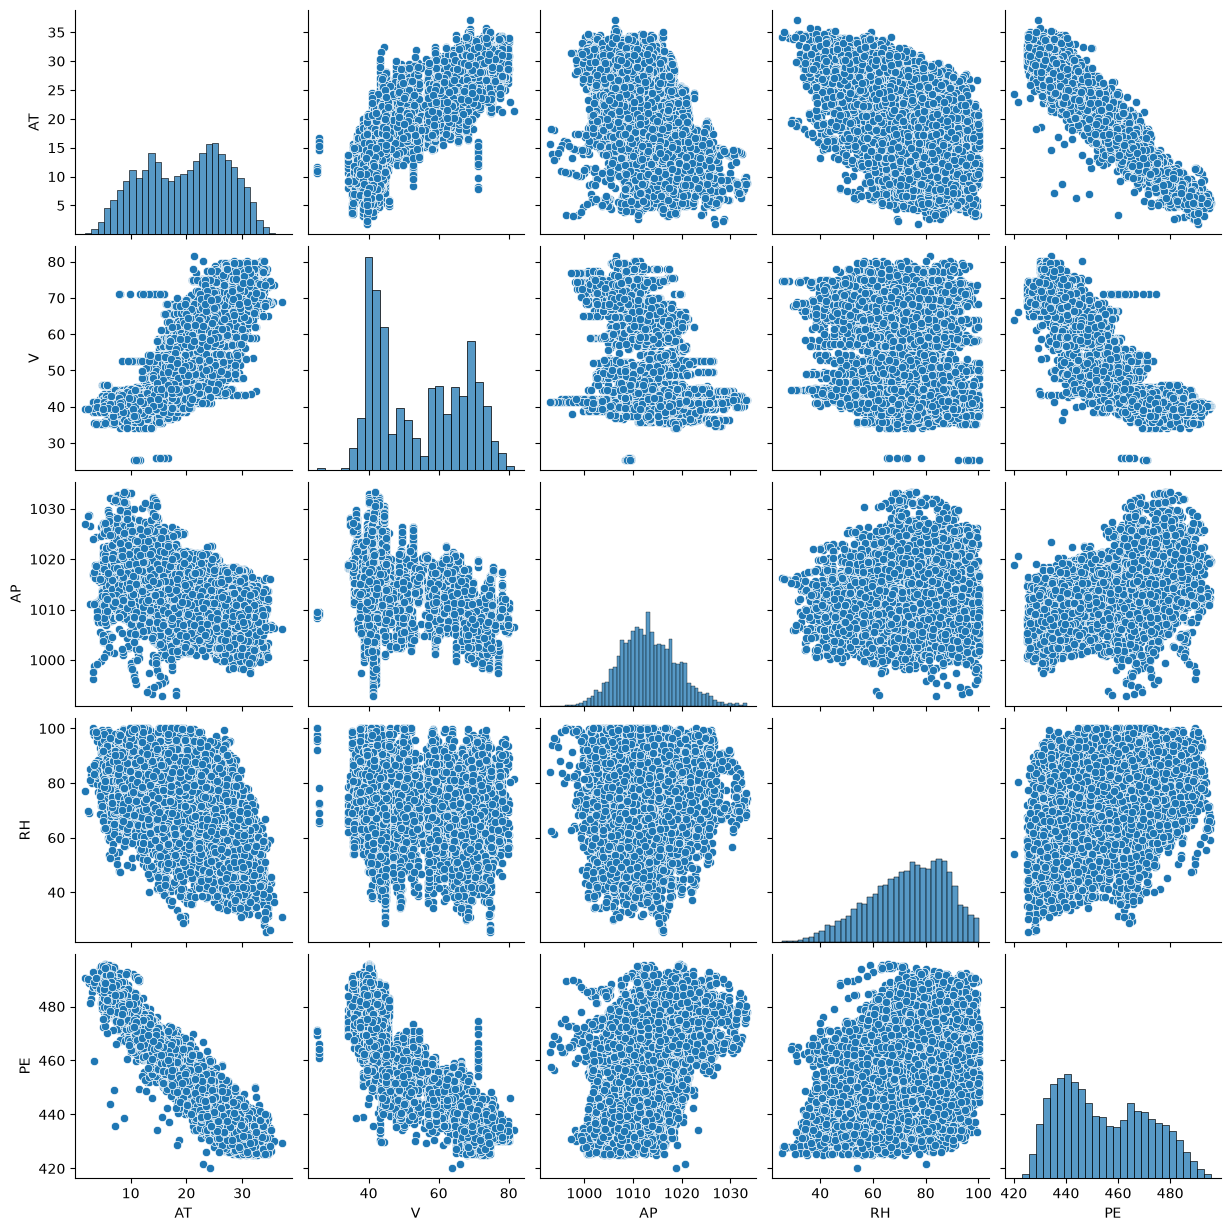

In [6]:
sns.pairplot(df)
plt.show()

**1(b)(ii)**

From the pairwise scatterplots:

- **AT and PE:** There is a strong negative association. As ambient temperature increases, electrical power output generally decreases. The relationship also appears to have some curvature.

- **V and PE:** There is also a negative association, although it is more scattered and less linear than the relationship between AT and PE.

- **AP and PE:** There is a positive but weaker association. Higher ambient pressure generally corresponds to higher electrical power output.

- **RH and PE:** There appears to be a relatively weak positive association, with substantial variation in PE for a given RH.

Among the predictors, **AT and V have a noticeable positive association**, while AT appears to have negative associations with AP and RH. Some plots, especially those involving V, also show clustering or band-like patterns.

Overall, **AT appears to have the strongest relationship with PE** among the four predictors. The plots also suggest that some relationships may not be perfectly linear.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [7]:
summary_statistics = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary_statistics.round(2)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple Linear Regression

In [8]:
model_AT = smf.ols("PE ~ AT", data=df).fit()

print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:55:24   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.0

In [ ]:
# Regression Models
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}

for predictor in predictors:
    model = smf.ols(f"PE ~ {predictor}", data=df).fit()
    simple_models[predictor] = model

    print(f"\n{'=' * 60}")
    print(f"Simple Linear Regression: PE ~ {predictor}")
    print("=" * 60)
    print(model.summary())



Simple Linear Regression: PE ~ AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:59:02   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.

In [11]:
simple_regression_results = pd.DataFrame({
    predictor: {
        "Intercept": simple_models[predictor].params["Intercept"],
        "Coefficient": simple_models[predictor].params[predictor],
        "P-value": simple_models[predictor].pvalues[predictor],
        "R-squared": simple_models[predictor].rsquared
    }
    for predictor in predictors
}).T

simple_regression_results

,Intercept,Coefficient,P-value,R-squared
AT,497.034120,-2.171320,0.0,0.898948
V,517.801526,-1.168135,0.0,0.756518
AP,-1055.260989,1.489872,0.0,0.268769
RH,420.961766,0.455650,0.0,0.151939


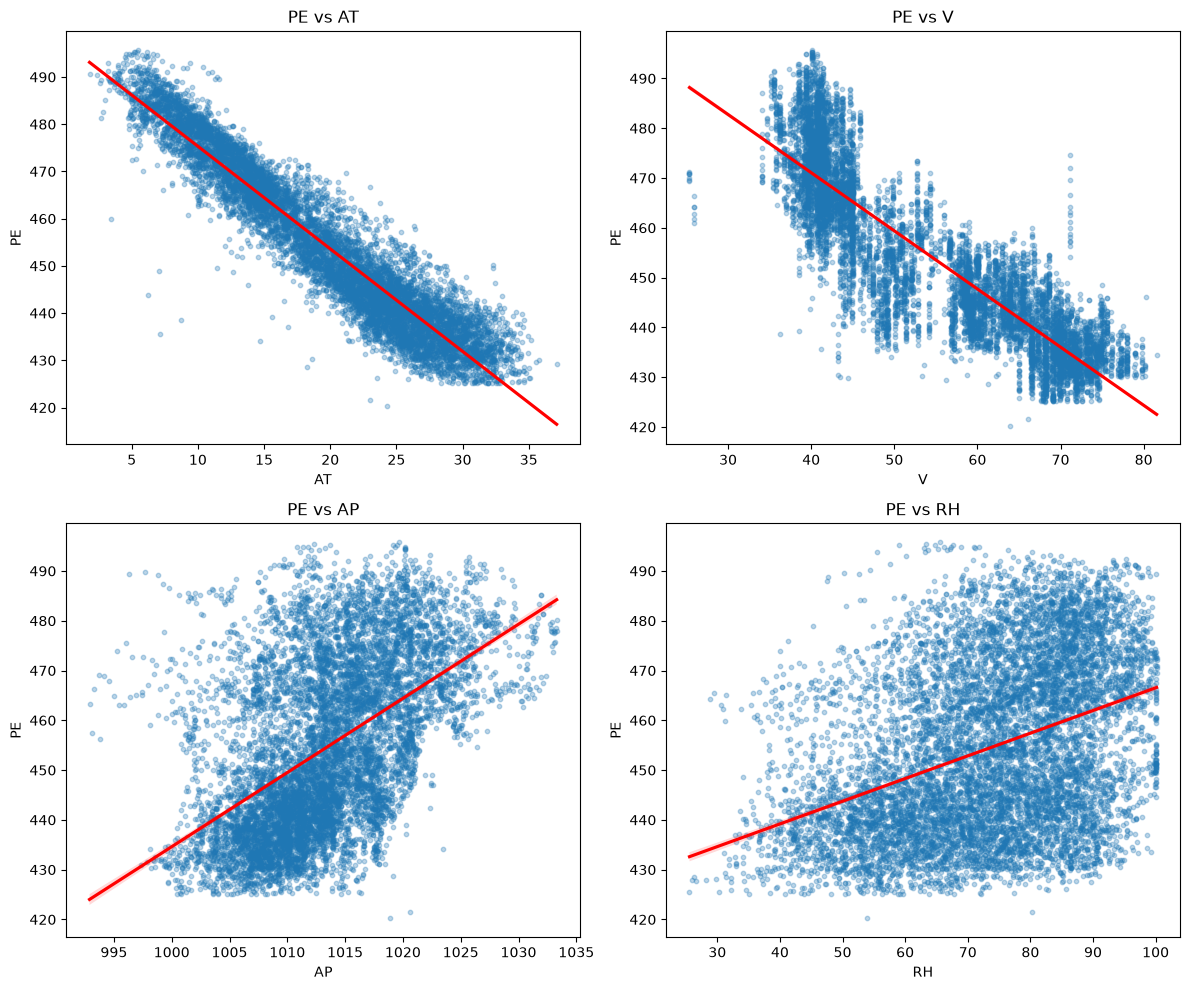

In [13]:
# Create a 2x2 grid for the four simple linear regression plots.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):

    # Plot observations and the fitted simple linear regression line.
    sns.regplot(
        data=df,
        x=predictor,
        y="PE",
        ax=ax,
        scatter_kws={"alpha": 0.3, "s": 10},
        line_kws={"color": "red"}
    )

    ax.set_title(f"PE vs {predictor}")

plt.tight_layout()
plt.show()

In [14]:
outlier_results = {}

for predictor in predictors:
    model = simple_models[predictor]

    # Calculate influence measures for each observation.
    influence = model.get_influence()

    # Studentized residuals help identify observations far from the fitted line.
    studentized_residuals = influence.resid_studentized_external

    # Flag observations with an absolute studentized residual greater than 3.
    outlier_mask = np.abs(studentized_residuals) > 3

    outlier_results[predictor] = {
        "Number of Potential Outliers": outlier_mask.sum(),
        "Percentage (%)": outlier_mask.mean() * 100
    }

# Summarize potential outliers for all four regression models.
outlier_summary = pd.DataFrame(outlier_results).T

outlier_summary.round(2)

,Number of Potential Outliers,Percentage (%)
AT,42.0,0.44
V,33.0,0.34
AP,30.0,0.31
RH,2.0,0.02




Four simple linear regression models were fitted separately using AT, V, AP, and RH to predict PE.

### Regression Results

- **AT:** The coefficient is **-2.1713** with an $R^2$ of **0.8989**. This indicates a strong negative association between AT and PE. A one-unit increase in AT is associated with an estimated **2.17-unit decrease** in PE.

- **V:** The coefficient is **-1.1681** with an $R^2$ of **0.7565**. V also has a negative association with PE, although the model explains less variation in PE than the AT model.

- **AP:** The coefficient is **1.4899** with an $R^2$ of **0.2688**. AP has a positive association with PE, but the relationship is considerably weaker than those of AT and V.

- **RH:** The coefficient is **0.4557** with an $R^2$ of **0.1519**. RH has a positive association with PE, but it has the weakest linear relationship with PE among the four predictors.

### Statistical Significance

The p-values for AT, V, AP, and RH are all **less than 0.001**. Therefore, at a significance level of $\alpha = 0.05$, the null hypothesis

$H_0: \beta_1 = 0$

is rejected for all four simple linear regression models. Thus, each predictor has a statistically significant linear association with PE when considered individually.

The regression plots support these results. AT and V show clear negative trends, while AP and RH show positive trends. The observations are much more closely distributed around the fitted regression line for AT and V than for AP and RH, which is consistent with their higher $R^2$ values.

### Potential Outliers

Using $|\text{studentized residual}| > 3$ as a criterion, the models identified:

- **AT:** 42 potential outliers (0.44%)
- **V:** 33 potential outliers (0.34%)
- **AP:** 30 potential outliers (0.31%)
- **RH:** 2 potential outliers (0.02%)

These observations represent only a small fraction of the dataset. A large studentized residual indicates that an observation is unusual relative to the fitted linear model, but it does not necessarily indicate an erroneous observation. Therefore, without additional evidence of measurement or data-entry errors, I would **not remove these observations** from the regression analyses.

### (d) Multiple Regression

In [15]:
# Fit a multiple linear regression model using all four predictors.
multiple_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=df
).fit()

# Display the full regression results.
print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:46:55   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

In [20]:
# Extract the coefficients and p-values from the multiple regression model.
multiple_regression_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "P-value": multiple_model.pvalues
})

multiple_regression_results

,Coefficient,P-value
Intercept,454.609274,0.000000e+00
AT,-1.977513,0.000000e+00
V,-0.233916,4.375305e-215
AP,0.062083,5.507109e-11
RH,-0.158054,3.104584e-293


In [21]:
print("R-squared:", multiple_model.rsquared)
print("Adjusted R-squared:", multiple_model.rsquared_adj)

R-squared: 0.9286960898122537
Adjusted R-squared: 0.9286662648994909




The multiple linear regression model is:

$$
\widehat{PE}
= 454.6093 - 1.9775AT - 0.2339V + 0.0621AP - 0.1581RH
$$

The model has an $R^2$ of **0.9287**, meaning that approximately **92.87%** of the variation in PE is explained by the four predictors.

All four predictors have **p-values < 0.05**, so we reject $H_0: \beta_j = 0$ for **AT, V, AP, and RH**. Therefore, all four predictors are statistically significant in the multiple regression model.

### (e) 1c Compare to 1d

In [22]:
# Extract coefficients from the simple and multiple regression models.
coefficient_comparison = pd.DataFrame({
    "Simple Regression": [
        simple_models[predictor].params[predictor]
        for predictor in predictors
    ],
    "Multiple Regression": [
        multiple_model.params[predictor]
        for predictor in predictors
    ]
}, index=predictors)

coefficient_comparison

,Simple Regression,Multiple Regression
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


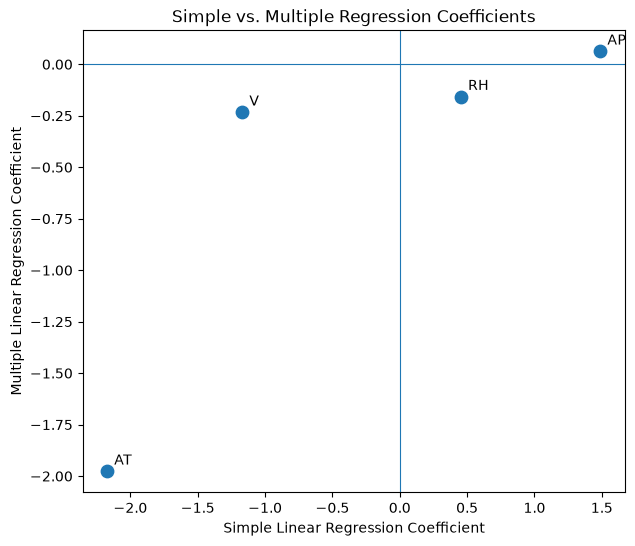

In [23]:
# Plot simple regression coefficients against multiple regression coefficients.
plt.figure(figsize=(7, 6))

plt.scatter(
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"],
    s=80
)

# Label each point with its predictor name.
for predictor in predictors:
    x = coefficient_comparison.loc[predictor, "Simple Regression"]
    y = coefficient_comparison.loc[predictor, "Multiple Regression"]

    plt.annotate(
        predictor,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Simple Linear Regression Coefficient")
plt.ylabel("Multiple Linear Regression Coefficient")
plt.title("Simple vs. Multiple Regression Coefficients")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.show()



The regression coefficients change when all predictors are included in the multiple regression model. The coefficients of **V and AP become much smaller in magnitude**, while **AT changes relatively little**. The coefficient of **RH changes from positive to negative**.

These differences occur because the simple regression models consider each predictor individually, while the multiple regression model estimates each predictor's association with PE while controlling for the other predictors.

### (f) Nonlinear Association

In [25]:
polynomial_models = {}

for predictor in predictors:
    # Fit a cubic polynomial regression: X, X^2, and X^3.
    model = smf.ols(
        f"PE ~ {predictor} + I({predictor}**2) + I({predictor}**3)",
        data=df
    ).fit()

    polynomial_models[predictor] = model

/var/folders/sn/h6m_26tx71b8fgwm7r9rhrfh0000gn/T/ipykernel_96160/814839005.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()


In [26]:
nonlinear_results = []

for predictor in predictors:
    model = polynomial_models[predictor]

    # Store coefficients and p-values for the linear, quadratic, and cubic terms.
    nonlinear_results.append({
        "Predictor": predictor,
        "Linear Coef": model.params[predictor],
        "Linear P-value": model.pvalues[predictor],
        "Quadratic Coef": model.params[f"I({predictor} ** 2)"],
        "Quadratic P-value": model.pvalues[f"I({predictor} ** 2)"],
        "Cubic Coef": model.params[f"I({predictor} ** 3)"],
        "Cubic P-value": model.pvalues[f"I({predictor} ** 3)"],
        "R-squared": model.rsquared
    })

nonlinear_results = pd.DataFrame(nonlinear_results).set_index("Predictor")

nonlinear_results

,Linear Coef,Linear P-value,Quadratic Coef,Quadratic P-value,Cubic Coef,Cubic P-value,R-squared
Predictor,,,,,,,
AT,-0.610346,7.898147e-07,-0.125138,8.833045e-73,0.002675,3.652185e-110,0.911883
V,-2.144377,2.526589e-05,-0.002712,7.684969e-01,0.000134,1.373489e-02,0.775022
AP,25.255593,4.502735e-17,-0.049952,3.666705e-17,0.000025,8.264146e-18,0.274863
RH,-1.729211,3.772510e-04,0.032145,9.395430e-06,-0.000152,1.440279e-05,0.153743




The polynomial regression results provide evidence of nonlinear associations between **all four predictors and PE**.

- **AT:** Both the quadratic and cubic terms are statistically significant.
- **V:** The quadratic term is not significant ($p = 0.768$), but the cubic term is significant ($p = 0.014$).
- **AP:** Both the quadratic and cubic terms are statistically significant.
- **RH:** Both the quadratic and cubic terms are statistically significant.

Therefore, there is evidence of nonlinear association with PE for **AT, V, AP, and RH**.

### (g) Interactions of Predictors

In [27]:
# Fit a full linear regression model with all pairwise interactions.
interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2",
    data=df
).fit()

# Display the full regression results.
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:15:09   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [28]:
# Extract only the pairwise interaction terms.
interaction_terms = [
    "AT:V",
    "AT:AP",
    "AT:RH",
    "V:AP",
    "V:RH",
    "AP:RH"
]

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "P-value": interaction_model.pvalues[interaction_terms]
})

interaction_results

,Coefficient,P-value
AT:V,0.020971,3.333358e-117
AT:AP,0.001759,4.520509e-01
AT:RH,-0.005230,1.216944e-10
V:AP,0.006812,2.877026e-07
V:RH,0.000839,8.619366e-02
AP:RH,-0.001612,3.360557e-02



At a significance level of $\alpha = 0.05$, the interaction terms **AT:V, AT:RH, V:AP, and AP:RH** are statistically significant.

The interactions **AT:AP** and **V:RH** are not statistically significant because their p-values are greater than 0.05.

Therefore, there is evidence that several pairs of predictors interact in their association with PE.

### (h) Improvement

In [29]:
# Randomly split the dataset into 70% training and 30% testing data.
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

Training observations: 6697
Testing observations: 2871


In [30]:
# Baseline model using all four predictors.
baseline_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train_df
).fit()

In [31]:
# Full model with all main effects, quadratic terms, and pairwise interactions.
full_formula = (
    "PE ~ AT + V + AP + RH"
    " + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)"
    " + AT:V + AT:AP + AT:RH"
    " + V:AP + V:RH + AP:RH"
)

full_model = smf.ols(
    full_formula,
    data=train_df
).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:17:25   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

In [32]:
# Summarize coefficients and p-values from the full model.
full_model_results = pd.DataFrame({
    "Coefficient": full_model.params,
    "P-value": full_model.pvalues
})

full_model_results

,Coefficient,P-value
Intercept,-7664.980854,8.518151e-08
AT,-7.288543,4.460633e-02
V,-1.958957,2.671816e-01
AP,15.930817,9.534685e-09
RH,3.912130,1.429286e-04
I(AT ** 2),0.018495,5.017196e-07
I(V ** 2),-0.000365,6.998020e-01
I(AP ** 2),-0.007758,8.522142e-09
I(RH ** 2),-0.001895,1.395087e-09
AT:V,0.009465,3.195237e-03


In [33]:
# Reduced model after removing insignificant higher-order terms.
# Main effects are retained to preserve model hierarchy.
reduced_formula = (
    "PE ~ AT + V + AP + RH"
    " + I(AT**2) + I(AP**2) + I(RH**2)"
    " + AT:V + AT:RH + AP:RH"
)

reduced_model = smf.ols(
    reduced_formula,
    data=train_df
).fit()

# Check whether the remaining terms are significant.
reduced_results = pd.DataFrame({
    "Coefficient": reduced_model.params,
    "P-value": reduced_model.pvalues
})

reduced_results

,Coefficient,P-value
Intercept,-10457.507603,1.325324e-21
AT,-2.429290,2.671314e-124
V,-0.454214,4.960489e-45
AP,21.153085,1.534727e-22
RH,5.675420,6.572307e-14
I(AT ** 2),0.016994,8.530847e-14
I(AP ** 2),-0.010195,1.653455e-21
I(RH ** 2),-0.002078,2.519751e-14
AT:V,0.008017,3.753670e-08
AT:RH,-0.006881,2.412307e-15


In [ ]:
# generate predictions from the baseline model.
baseline_train_pred = baseline_model.predict(train_df)
baseline_test_pred = baseline_model.predict(test_df)

# generate predictions from the reduced/improved model.
reduced_train_pred = reduced_model.predict(train_df)
reduced_test_pred = reduced_model.predict(test_df)

# calculate training and testing MSE for both models.
mse_results = pd.DataFrame({
    "Train MSE": [
        mean_squared_error(train_df["PE"], baseline_train_pred),
        mean_squared_error(train_df["PE"], reduced_train_pred)
    ],
    "Test MSE": [
        mean_squared_error(test_df["PE"], baseline_test_pred),
        mean_squared_error(test_df["PE"], reduced_test_pred)
    ]
}, index=["Baseline Linear Model", "Improved Model"])

mse_results.round(4)

,Train MSE,Test MSE
Baseline Linear Model,20.5808,21.2399
Improved Model,17.9178,18.6943



The baseline linear model has a **train MSE of 20.5808** and a **test MSE of 21.2399**.

After including significant quadratic and interaction terms while maintaining model hierarchy, the improved model has a **train MSE of 17.9178** and a **test MSE of 18.6943**.

Since the improved model has lower MSE on both the training and test sets, the additional nonlinear and interaction terms improve the predictive performance of the model.

### (i) KNN

In [35]:
# use the same train_df and test_df from 1(h)
# separate predictors (X) and response (y) for training and testing.
X_train = train_df[predictors]
y_train = train_df["PE"]

X_test = test_df[predictors]
y_test = test_df["PE"]

# fit the scaler only on the training data to avoid data leakage.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# apply the same scaling learned from training data to test data.
X_test_scaled = scaler.transform(X_test)

k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    # fit KNN regression using raw features.
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    # predict PE for training and testing data.
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    # store the MSE for each value of k.
    raw_train_mse.append(
        mean_squared_error(y_train, train_pred)
    )
    raw_test_mse.append(
        mean_squared_error(y_test, test_pred)
    )

# find the k with the lowest test MSE for raw features.
best_raw_index = np.argmin(raw_test_mse)
best_raw_k = list(k_values)[best_raw_index]
best_raw_test_mse = raw_test_mse[best_raw_index]

print("Best k for raw features:", best_raw_k)
print("Best test MSE for raw features:", best_raw_test_mse)

Best k for raw features: 5
Best test MSE for raw features: 15.726819842563568


In [36]:
scaled_train_mse = []
scaled_test_mse = []

for k in k_values:
    # fit KNN regression using standardized features.
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)

    scaled_train_mse.append(
        mean_squared_error(y_train, train_pred)
    )
    scaled_test_mse.append(
        mean_squared_error(y_test, test_pred)
    )

# find the k with the lowest test MSE for standardized features.
best_scaled_index = np.argmin(scaled_test_mse)
best_scaled_k = list(k_values)[best_scaled_index]
best_scaled_test_mse = scaled_test_mse[best_scaled_index]

print("Best k for normalized features:", best_scaled_k)
print("Best test MSE for normalized features:", best_scaled_test_mse)

Best k for normalized features: 4
Best test MSE for normalized features: 14.305669422675024


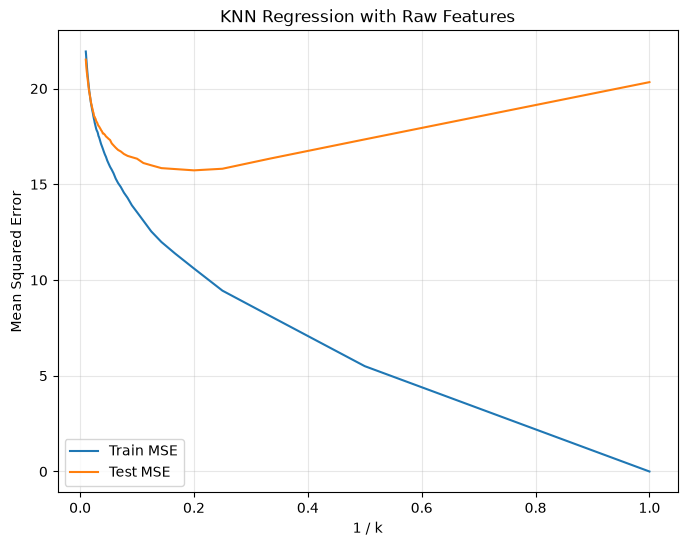

In [38]:
# convert k to 1/k for the x-axis.
inverse_k = 1 / np.array(list(k_values))

plt.figure(figsize=(8, 6))

plt.plot(inverse_k, raw_train_mse, label="Train MSE")
plt.plot(inverse_k, raw_test_mse, label="Test MSE")

plt.xlabel("1 / k")
plt.ylabel("Mean Squared Error")
plt.title("KNN Regression with Raw Features")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

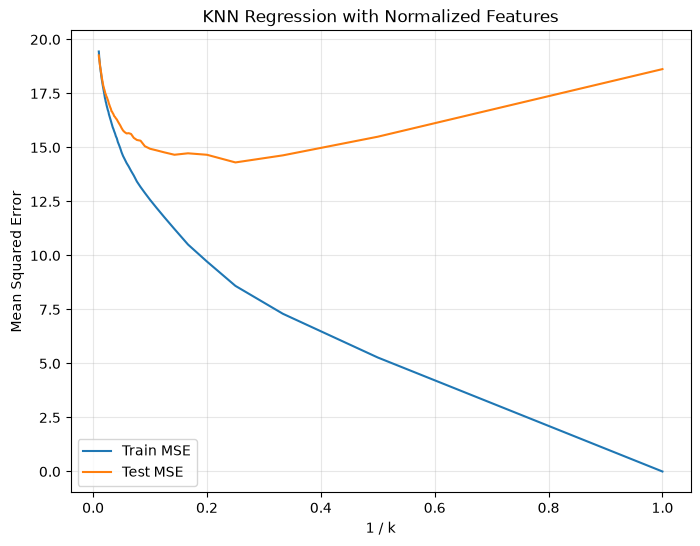

In [39]:
# plot training and testing MSE for standardized features.
plt.figure(figsize=(8, 6))

plt.plot(inverse_k, scaled_train_mse, label="Train MSE")
plt.plot(inverse_k, scaled_test_mse, label="Test MSE")

plt.xlabel("1 / k")
plt.ylabel("Mean Squared Error")
plt.title("KNN Regression with Normalized Features")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


For the **raw features**, the best value is **$k=5$**, with a test MSE of **15.7268**.

For the **normalized features**, the best value is **$k=4$**, with a test MSE of **14.3057**.

The normalized KNN model achieves a lower test error than the raw KNN model. At $k=1$, the training MSE is zero, but the test MSE is higher, indicating overfitting.

### (j ) Compare KNN and Linear

In [40]:
# Compare the test performance of the best regression and KNN models.
model_comparison = pd.DataFrame({
    "Model": [
        "Improved Linear Regression",
        "KNN (Raw Features)",
        "KNN (Normalized Features)"
    ],
    "Best k": [
        np.nan,
        best_raw_k,
        best_scaled_k
    ],
    "Test MSE": [
        mse_results.loc["Improved Model", "Test MSE"],
        best_raw_test_mse,
        best_scaled_test_mse
    ]
})

# Sort models from lowest to highest test MSE.
model_comparison = model_comparison.sort_values("Test MSE").reset_index(drop=True)

model_comparison.round(4)

,Model,Best k,Test MSE
0,KNN (Normalized Features),4.0,14.3057
1,KNN (Raw Features),5.0,15.7268
2,Improved Linear Regression,NaN,18.6943



Both KNN models have lower test MSEs than the improved linear regression model. Among the models compared, the **normalized KNN model ($k=4$)** has the lowest test MSE.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.



A flexible method would generally perform better. Since n is extremely large relative to p, there is enough data to estimate a more complex relationship while reducing the risk of overfitting.

### (b) The number of predictors p is extremely large, and the number of observations n is small.



In this case, flexible method would generally perform worse. Since p is extremely large relative to n, a flexible model is more likely to overfit the limited observations, resulting in high variance and poor performance on new data.

### (c) The relationship between the predictors and response is highly non-linear.



Flexible method would generally perform better. Since the relationship between the predictors and response is highly non-linear, a flexible method is better able to capture the complex shape of the true relationship.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.



Flexible method would generally perform worse. When the error variance is extremely high, the data contain a large amount of noise. A flexible method is more likely to fit this noise, leading to overfitting and higher variance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.



The Euclidean distance from each observation to the test point (0, 0, 0) is calculated using:

d = sqrt((X1 - 0)^2 + (X2 - 0)^2 + (X3 - 0)^2)

The distances are:

- Observation 1: sqrt(0^2 + 3^2 + 0^2) = 3
- Observation 2: sqrt(2^2 + 0^2 + 0^2) = 2
- Observation 3: sqrt(0^2 + 1^2 + 3^2) = sqrt(10) = 3.162
- Observation 4: sqrt(0^2 + 1^2 + 2^2) = sqrt(5) = 2.236
- Observation 5: sqrt((-1)^2 + 0^2 + 1^2) = sqrt(2) = 1.414
- Observation 6: sqrt(1^2 + 1^2 + 1^2) = sqrt(3) = 1.732

### (b) What is our prediction with K = 1? Why?



For K = 1, we only consider the nearest neighbor.

Observation 5 has the smallest distance: d5 = sqrt(2) = 1.414

Since Observation 5 belongs to the **Green** class, the prediction is: Prediction = Green

### (c) What is our prediction with K = 3? Why?



For K = 3, the three nearest neighbors are:

1. Observation 5: distance = 1.414, Green
2. Observation 6: distance = 1.732, Red
3. Observation 2: distance = 2.000, Red

The majority vote is: Red = 2, Green = 1

Therefore: Prediction = Red

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?



We would expect the best value of K to be **small**.

Small K -> more flexible decision boundary

Large K -> less flexible and smoother decision boundary

Therefore, a small K is better able to capture a highly non-linear Bayes decision boundary.